# Lab 4 — Synchronization: Carrier, Timing and Frame

**Companion to Chapter 4.** A coherent receiver must estimate four unknowns
before it can detect a single bit: frequency offset, carrier phase, symbol timing
and frame start. This lab builds each loop from scratch (see `commlib/sync.py`)
and then chains them into a complete burst receiver.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import commlib as cl

cl.style()
rng = np.random.default_rng(4)
qpsk = cl.get_constellation("qpsk")
sps = 4
h = cl.rrc_taps(0.35, sps, 10)

## 1. What each impairment does to the constellation

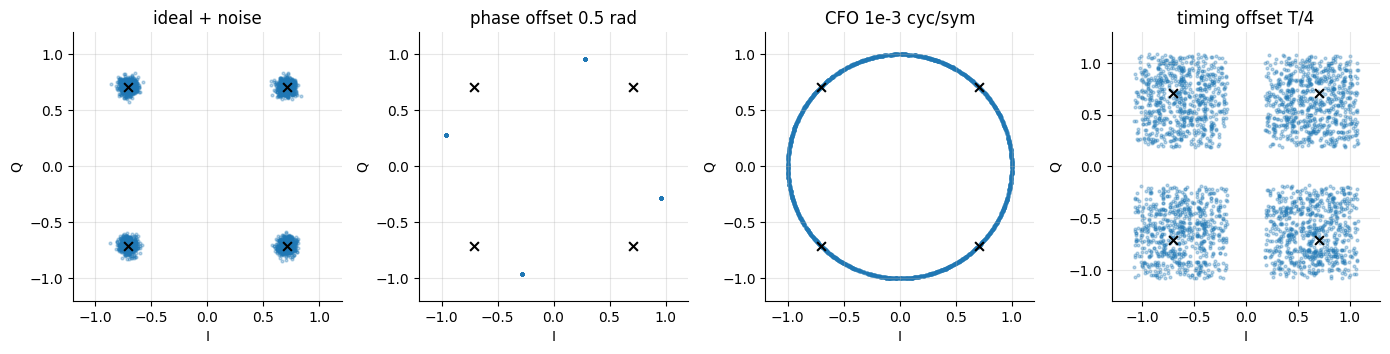

In [3]:
s = qpsk.modulate(cl.random_bits(2 * 3000, rng))
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
cl.plot_constellation(ax[0], cl.awgn(s, 25, rng), qpsk.points, "ideal + noise")
cl.plot_constellation(ax[1], s * np.exp(1j * 0.5), qpsk.points, "phase offset 0.5 rad")
cl.plot_constellation(ax[2], cl.apply_cfo(s, 1e-3), qpsk.points, "CFO 1e-3 cyc/sym")
x = cl.matched_filter(cl.shape(s, h, sps), h)
cl.plot_constellation(ax[3], x[len(h) - 1 + 1::sps][:3000], qpsk.points, "timing offset T/4")
plt.tight_layout(); plt.show()

## 2. Coarse CFO: the M-th power estimator
Raising M-PSK to the M-th power strips the modulation and leaves a tone at
$M\,\Delta f$. The FFT peak gives $\Delta f$ with an unambiguous range of
$\pm R_s/(2M)$, and the estimator approaches the Cramér–Rao bound at high SNR.

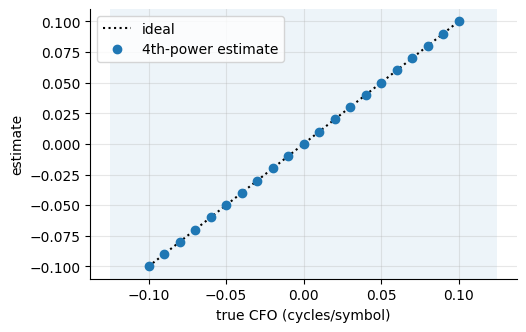

In [5]:
true_f = np.linspace(-0.1, 0.1, 21)
est = [cl.cfo_power_estimate(cl.awgn(cl.apply_cfo(s[:2048], f), 15, rng), 4) for f in true_f]
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(true_f, true_f, "k:", label="ideal"); ax.plot(true_f, est, "o", label="4th-power estimate")
ax.axvspan(-0.125, 0.125, alpha=0.08); ax.set_xlabel("true CFO (cycles/symbol)"); ax.set_ylabel("estimate")
ax.legend(); plt.show()

## 3. The second-order PLL: acquisition versus jitter
A decision-directed PLL with a PI loop filter tracks both phase and residual
frequency. The loop noise bandwidth $B_nT$ sets the trade-off: wide loops pull in
fast but pass more noise to the phase estimate.

### Interactive
Change $B_nT$, CFO and SNR. Watch the phase estimate converge (left) and the
resulting constellation after the loop settles (right).

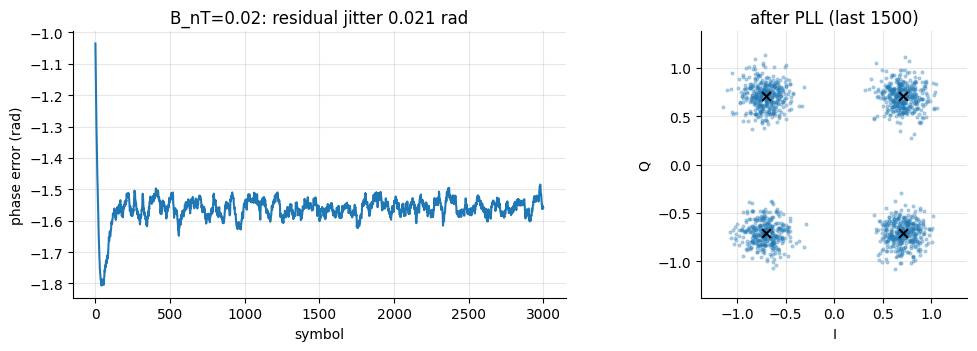

In [7]:
def pll_demo(bn=0.02, cfo=0.002, esn0_db=15.0, mod="qpsk"):
    c = cl.get_constellation(mod)
    sym = c.modulate(cl.random_bits(c.k * 3000, rng))
    y = cl.apply_cfo(sym, cfo, 1.0)
    y, _ = cl.awgn_esn0(y, esn0_db, rng=rng)
    z, ph = cl.pll_dd(y, c, bn=bn)
    true_ph = 2 * np.pi * cfo * np.arange(len(y)) + 1.0
    err = np.angle(np.exp(1j * (ph - true_ph)))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].plot(err); ax[0].set_xlabel("symbol"); ax[0].set_ylabel("phase error (rad)")
    q = 2 * np.pi / (4 if c.M >= 4 else 2)
    ax[0].set_title(f"B_nT={bn}: residual jitter {np.std(np.angle(np.exp(1j*q*err[-1000:]/q))):.3f} rad")
    cl.plot_constellation(ax[1], z[-1500:], c.points, "after PLL (last 1500)")
    plt.tight_layout(); plt.show()

interact(pll_demo, bn=FloatSlider(value=0.02, min=0.001, max=0.1, step=0.001, readout_format=".3f"),
         cfo=FloatSlider(value=0.002, min=0, max=0.02, step=0.0005, readout_format=".4f"),
         esn0_db=FloatSlider(value=15, min=3, max=30, step=1),
         mod=["qpsk", "bpsk", "8psk", "16qam"]);

Note the phase error often settles at a multiple of 90°: decision-directed loops
for QPSK have a four-fold **phase ambiguity**. Real systems resolve it with a
known preamble (below) or with differential encoding.

## 4. Symbol timing recovery: the Gardner detector
The Gardner TED works at 2+ samples/symbol and is independent of carrier phase:
$e[k] = \mathrm{Re}\{y^*(kT - T/2)\,[y(kT) - y((k-1)T)]\}$.
Its average output versus timing offset (the *S-curve*) crosses zero with
positive slope at the correct instant.

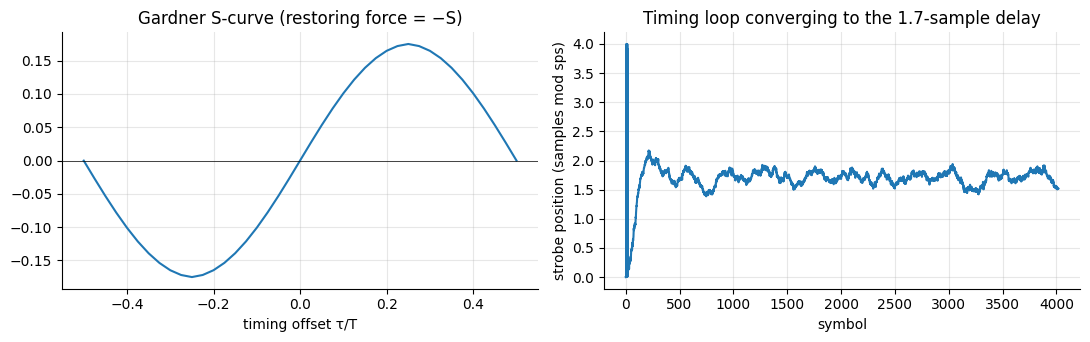

In [10]:
sym = qpsk.modulate(cl.random_bits(2 * 4000, rng))
y = cl.matched_filter(cl.shape(sym, h, sps), h)
d0 = len(h) - 1
taus = np.linspace(-0.5, 0.5, 41)
S = []
for tau in taus:
    t = d0 + (np.arange(20, 3900) + tau) * sps
    cur, prev, mid = cl.interp_cubic(y, t), cl.interp_cubic(y, t - sps), cl.interp_cubic(y, t - sps / 2)
    S.append(np.mean(np.real(np.conj(mid) * (cur - prev))))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(taus, S); ax[0].axhline(0, color="k", lw=0.5); ax[0].set_xlabel("timing offset τ/T")
ax[0].set_title("Gardner S-curve (restoring force = −S)")
yd = cl.fractional_delay(np.concatenate([y, np.zeros(10)]), 1.7)
yd, _ = cl.awgn_esn0(yd, 20, sps=sps, rng=rng)
syms, e, tau_hist = cl.gardner_sync(yd, sps, bn=0.01)
ax[1].plot(tau_hist); ax[1].set_xlabel("symbol"); ax[1].set_ylabel("strobe position (samples mod sps)")
ax[1].set_title("Timing loop converging to the 1.7-sample delay"); plt.tight_layout(); plt.show()

## 5. Frame synchronization with a Zadoff–Chu preamble
CAZAC sequences such as Zadoff–Chu have constant amplitude and ideal periodic
autocorrelation, which is why NR uses them for PSS-like sequences and PRACH.
The correlation peak gives frame timing, and the complex peak value gives the
channel phase, which resolves the PLL's ambiguity.

detected start = 137 (true 137), phase = 2.16 rad (true 2.20)


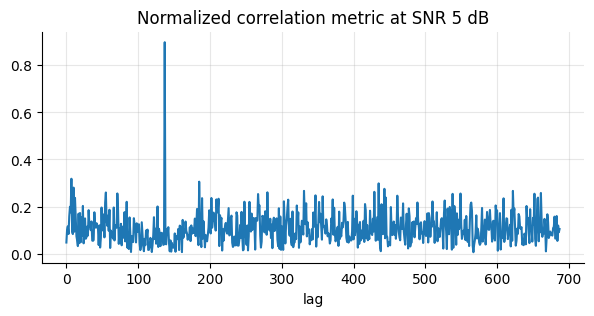

In [12]:
zc = cl.zadoff_chu(25, 63)
payload = qpsk.modulate(cl.random_bits(2 * 500, rng))
burst = np.concatenate([np.zeros(137), zc, payload, np.zeros(50)]) * np.exp(1j * 2.2)
rx = cl.awgn(burst, 5, rng)
k, g, metric = cl.frame_sync(rx, zc)
print(f"detected start = {k} (true 137), phase = {np.angle(g):.2f} rad (true 2.20)")
fig, ax = plt.subplots(figsize=(7, 3)); ax.plot(metric); ax.set_title("Normalized correlation metric at SNR 5 dB")
ax.set_xlabel("lag"); plt.show()

## 6. Putting it together: a complete burst receiver
Chain: matched filter → Gardner timing → 4th-power coarse CFO → DD-PLL → preamble
correlation for frame start and phase ambiguity → decisions. The input has a
fractional delay, CFO and noise, like a real over-the-air burst.

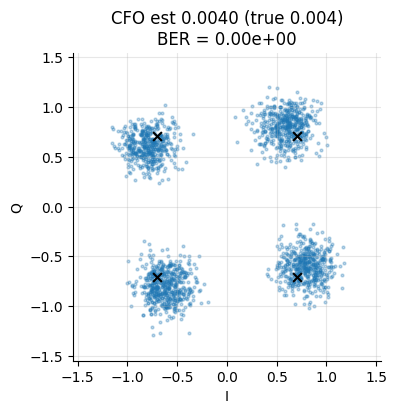

In [14]:
def burst_rx_demo(cfo=0.004, delay=2.3, esn0_db=14.0):
    pre = qpsk.modulate(np.tile([0, 0, 1, 1, 0, 1, 1, 0], 8))  # known 32-symbol preamble
    data_bits = cl.random_bits(2 * 2000, rng)
    tx_sym = np.concatenate([qpsk.modulate(cl.random_bits(2 * 200, rng)), pre, qpsk.modulate(data_bits)])
    x = cl.shape(tx_sym, h, sps)
    x = cl.fractional_delay(np.concatenate([x, np.zeros(20)]), delay)
    x = cl.apply_cfo(x, cfo / sps, 0.8)
    x, _ = cl.awgn_esn0(x, esn0_db, sps=sps, rng=rng)
    y = cl.matched_filter(x, h)
    syms, _, _ = cl.gardner_sync(y, sps, bn=0.01)
    f_hat = cl.cfo_power_estimate(syms[:1024], 4)
    syms = cl.apply_cfo(syms, -f_hat)
    z, _ = cl.pll_dd(syms, qpsk, bn=0.01)
    k, g, _ = cl.frame_sync(z, pre)
    z = z * np.exp(-1j * np.angle(g))           # resolve 90° ambiguity
    data = z[k + len(pre): k + len(pre) + 2000]
    ber = np.mean(qpsk.demodulate(data) != data_bits[:2 * len(data)])
    fig, ax = plt.subplots(figsize=(4, 4))
    cl.plot_constellation(ax, data, qpsk.points, f"CFO est {f_hat:.4f} (true {cfo})\nBER = {ber:.2e}")
    plt.show()

interact(burst_rx_demo, cfo=FloatSlider(value=0.004, min=-0.03, max=0.03, step=0.001, readout_format=".3f"),
         delay=FloatSlider(value=2.3, min=0, max=4, step=0.1),
         esn0_db=FloatSlider(value=14, min=4, max=30, step=1));

## Exercises
1. **(Warm-up)** Derive the S-curve of the Gardner detector for an RC pulse and
   compare its slope at 0 with the `kd=2` default in `gardner_sync`.
2. **(Core)** Replace the 4th-power estimator with the data-aided Luise–Reggiannini
   or Fitz estimator using the preamble. Plot estimator MSE against the modified CRB
   $\mathrm{MCRB} = 3/(2\pi^2 N^3 E_s/N_0)$ (cycles²/symbol²).
3. **(Core)** Measure mean acquisition time of the PLL versus $B_nT$ and CFO. Explain
   the pull-in limit.
4. **(Stretch)** Implement the polyphase-filterbank clock recovery used by GNU Radio's
   `Symbol Sync`/`pfb_clock_sync` blocks and compare its jitter with the Gardner loop.